# Assignment 1 – Face Mask Detection


## Problem Statement



Fine-tune a pretrained MobileNet model on a face-mask dataset.
Evaluate precision, recall and inference speed.
Suggest optimizations for edge deployment.







## Dataset Description

The Face Mask Detection dataset contains RGB images of people wearing face masks and without face masks. The dataset consists of two classes:

- with_mask
- without_mask

The images are collected from multiple real-world sources and are suitable for binary image classification using transfer learning techniques.

## Dataset Attributes

- Dataset Name : Face Mask Detection Dataset
- Number of Classes : 2
- Classes : with_mask, without_mask
- Total Images : 7553
- Image Type : RGB
- Image Size : Resized to 224 × 224 pixels
- Learning Type : Binary Image Classification

In [15]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.metrics import (
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras import Sequential
from tensorflow.keras import Input

from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    RandomFlip,
    RandomRotation,
    RandomZoom
)

from tensorflow.keras.applications import MobileNetV2

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
dataset_path="/content/drive/MyDrive/FaceMaskDataset/data"

In [31]:
def load_dataset(dataset_path,image_size=(224,224),batch_size=32):
    train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset="training",
        seed=42,
        image_size=image_size,
        batch_size=batch_size
    )

    validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset="validation",
        seed=42,
        image_size=image_size,
        batch_size=batch_size
    )

    class_names = train_dataset.class_names

    normalization = tf.keras.layers.Rescaling(1./255)
    AUTOTUNE = tf.data.AUTOTUNE
    train_dataset = (
        train_dataset
        .map(lambda x,y:(normalization(x),y))
        .prefetch(AUTOTUNE)
    )

    validation_dataset = (
        validation_dataset
        .map(lambda x,y:(normalization(x),y))
        .prefetch(AUTOTUNE)
    )




    return train_dataset, validation_dataset, class_names

In [32]:
# Display Dataset Information

def display_dataset_info(train_dataset,validation_dataset,class_names):

    print("Classes :", class_names)
    print("Number of Classes :", len(class_names))
    print("Training Batches :", len(train_dataset))
    print("Validation Batches :", len(validation_dataset))
    for images, labels in train_dataset.take(1):
        print("Image Batch Shape :", images.shape)
        print("Label Batch Shape :", labels.shape)

In [33]:
# Create Data Augmentation
# Data augmentation artificially increases the diversity of the training dataset by applying random transformations to input images. This helps improve model generalization and reduces overfitting during training.
# Data Augmentation

def create_data_augmentation():

    data_augmentation = Sequential([
        RandomFlip("horizontal"),
        RandomRotation(0.1),
        RandomZoom(0.1)
    ])
    return data_augmentation

In [43]:
# Build MobileNetV2 Model

def build_mobilenet_model(data_augmentation,input_shape=(224,224,3)):

    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = True

    for layer in base_model.layers[:-20]:
        layer.trainable = False


    model = Sequential([
        Input(shape=input_shape),
        data_augmentation,
        base_model,
        GlobalAveragePooling2D(),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [44]:
# Display Model Summary

def display_model_summary(model):

    model.summary()

In [45]:
# Train Model

def train_model(model,train_dataset,validation_dataset,epochs=3):
    history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=epochs
    )

    return history

In [46]:
# Evaluate Model

def evaluate_model(model,validation_dataset):
    loss, accuracy = model.evaluate(validation_dataset)
    print(f"Validation Loss : {loss:.4f}")
    print(f"Validation Accuracy : {accuracy:.4f}")

    return loss, accuracy

In [47]:
# Plot Training History

def plot_training_history(history):

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

In [48]:
# Precision and Recall

def calculate_precision_recall(model,validation_dataset):

    y_true = []
    y_pred = []
    for images, labels in validation_dataset:
        predictions = model.predict(images, verbose=0)
        predictions = (predictions > 0.5).astype(int)
        y_true.extend(labels.numpy())
        y_pred.extend(predictions.flatten())

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    print(f"Precision : {precision:.4f}")
    print(f"Recall : {recall:.4f}")
    print("\nClassification Report\n")
    print(classification_report(y_true, y_pred))

    return precision, recall

In [49]:
# Measure Inference Speed

def measure_inference_speed(model,validation_dataset):

    for images, labels in validation_dataset.take(1):
        start = time.time()
        model.predict(images, verbose=0)
        end = time.time()
        inference_time = end - start
        average_time = inference_time / len(images)
        print(f"Average Inference Time : {average_time*1000:.2f} ms/image")

        return average_time

In [50]:
# Predict Sample Images

def predict_sample_images(model,validation_dataset,class_names,num_images=5):

    for images, labels in validation_dataset.take(1):
        predictions = model.predict(images, verbose=0)
        plt.figure(figsize=(15,5))

        for i in range(num_images):
            plt.subplot(1, num_images, i+1)
            plt.imshow(images[i].numpy())
            predicted_label = class_names[
                int(predictions[i] > 0.5)
            ]
            actual_label = class_names[
                labels[i]
            ]
            plt.title(
                f"P: {predicted_label}\nA: {actual_label}",
                fontsize=10
            )
            plt.axis("off")
        plt.show()

Found 7553 files belonging to 2 classes.
Using 6043 files for training.
Found 7553 files belonging to 2 classes.
Using 1510 files for validation.
Classes : ['with_mask', 'without_mask']
Number of Classes : 2
Training Batches : 189
Validation Batches : 48
Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32,)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,207,361 (4.61 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

Epoch 1/2
189/189 ━━━━━━━━━━━━━━━━━━━━ 80s 359ms/step - accuracy: 0.9732 - loss: 0.0761 - val_accuracy: 0.7874 - val_loss: 3.2105
Epoch 2/2
189/189 ━━━━━━━━━━━━━━━━━━━━ 31s 162ms/step - accuracy: 0.9881 - loss: 0.0355 - val_accuracy: 0.9589 - val_loss: 0.3496
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.9589 - loss: 0.3496
Validation Loss : 0.3496
Validation Accuracy : 0.9589


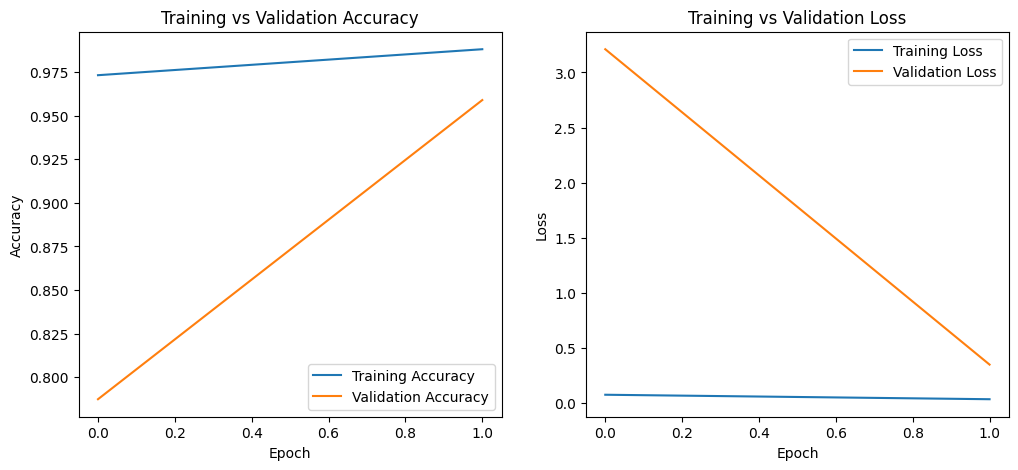

Precision : 1.0000
Recall : 0.9193

Classification Report

              precision    recall  f1-score   support

           0       0.92      1.00      0.96       742
           1       1.00      0.92      0.96       768

    accuracy                           0.96      1510
   macro avg       0.96      0.96      0.96      1510
weighted avg       0.96      0.96      0.96      1510

Average Inference Time : 3.82 ms/image


/tmp/ipykernel_542/746891032.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  int(predictions[i] > 0.5)


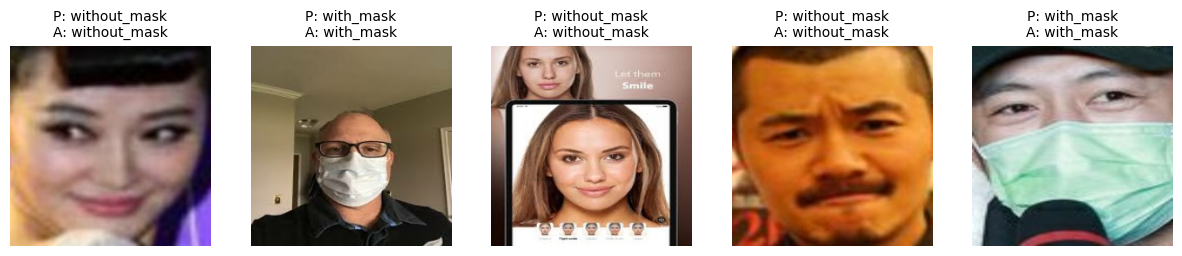

In [51]:
# Face Mask Detection Pipeline

IMAGE_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 2

train_dataset, validation_dataset, class_names = load_dataset(
    dataset_path,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)
display_dataset_info(
    train_dataset,
    validation_dataset,
    class_names
)
data_augmentation = create_data_augmentation()
model = build_mobilenet_model(
    data_augmentation
)
display_model_summary(model)
history = train_model(
    model,
    train_dataset,
    validation_dataset,
    epochs=EPOCHS
)
evaluate_model(
    model,
    validation_dataset
)
plot_training_history(history)
calculate_precision_recall(model,validation_dataset)
measure_inference_speed(model,validation_dataset)
predict_sample_images(model,validation_dataset,class_names)

## Observations

- The Face Mask Detection dataset consisting of **7,553 RGB images** was successfully loaded from Google Drive using TensorFlow's `image_dataset_from_directory()` function.
- The dataset was automatically divided into **80% training (approximately 6,043 images)** and **20% validation (approximately 1,510 images)** using `validation_split = 0.2`.
- All images were resized to **224 × 224 pixels** and normalized to the range **0–1**, making them suitable for MobileNetV2.
- Data augmentation techniques including **Random Horizontal Flip**, **Random Rotation (0.1)**, and **Random Zoom (0.1)** were applied during training to improve the model's ability to generalize to unseen images.
- A pretrained **MobileNetV2** model initialized with **ImageNet weights** was used for transfer learning, and the **last 20 layers** were fine-tuned while the remaining layers remained frozen.
- The model was trained using the **Adam optimizer**, **Binary Cross-Entropy loss**, a **batch size of 32**, and **2 training epochs**.
- The trained model achieved a **validation accuracy of 95.89%** with a **validation loss of 34.96%**.
- The evaluation produced a **precision of 100%** and a **recall of 91.93%**, indicating effective classification of both masked and unmasked face images.
- The measured **average inference speed was 3.82 ms/image**, demonstrating that the model is suitable for near real-time face mask detection.
- Sample prediction results showed that the model successfully classified images into the **with_mask** and **without_mask** categories with good consistency.
- The combination of transfer learning and fine-tuning significantly reduced the training time compared to training a convolutional neural network from scratch while maintaining high classification performance.